In [34]:

import os
import sys
import shutil

os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Important: remove broken/manual Spark path if it exists
os.environ.pop("SPARK_HOME", None)
os.environ.pop("HADOOP_HOME", None)

print("Python:", sys.executable)
print("Java:", shutil.which("java"))
print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("SPARK_HOME:", os.environ.get("SPARK_HOME"))

Python: e:\Uni-Stuff\Graduation-Project\ASR\Egypt_Property_Prices\.venv\Scripts\python.exe
Java: C:\Program Files\Java\jdk-17\bin\java.EXE
JAVA_HOME: C:\Program Files\Java\jdk-17
SPARK_HOME: None


# Egyptian Real Estate EDA

### setup

In [35]:
import os
import sys

# 1. Set the IP to localhost to avoid the "Invalid Spark URL" error
# os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

# # 2. Point to your Spark and Hadoop folders
# os.environ['SPARK_HOME'] = r'C:\spark-4.1.1-bin-hadoop3\spark-4.1.1-bin-hadoop3'
# os.environ['HADOOP_HOME'] = r'C:\Hadoop' 
# os.environ['PYSPARK_PYTHON'] = sys.executable
# os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# # 3. Add PySpark to your sys.path
# sys.path.append(os.path.join(os.environ['SPARK_HOME'], 'python'))
# sys.path.append(os.path.join(os.environ['SPARK_HOME'], 'python', 'lib', 'py4j-0.10.9.9-src.zip'))

# 4. Initialize Spark
from pyspark import SparkConf
from pyspark.sql import SparkSession
conf = SparkConf()
conf.set("spark.python.worker.timeout", "1200") # Set to 20 minutes
conf.set("spark.driver.memory", "4g")
conf.set("spark.executor.memory", "2g")
# If using a local-mode or single-node K8s, sometimes this helps:
conf.set("spark.driver.bindAddress", "127.0.0.1")
spark = SparkSession.builder \
    .appName("JupyterSparkTest") \
    .master("local[*]") \
    .config(conf=conf) \
    .getOrCreate()

sc = spark.sparkContext

### Load And Inspect Dataset

In [36]:
import pandas as pd
import numpy as np

In [37]:
# Define the path to your Egypt Property Prices dataset
PATH = "data/raw/propertyFinder.csv"

# Load the data into a Spark DataFrame
# inferSchema=True: Automatically detects data types (integers, strings, etc.)
df_raw = spark.read.csv(PATH, header=True, inferSchema=True)

# Print basic info to verify ingestion (Project Pipeline Step II)
print(f"Total Records: {df_raw.count():,}")
print(f"Total Columns: {len(df_raw.columns)}")
df_raw.printSchema()
df_raw.show(5)


Total Records: 39,713
Total Columns: 53
root
 |-- listing_id: string (nullable = true)
 |-- internal_id: double (nullable = true)
 |-- category: string (nullable = true)
 |-- listing_type: string (nullable = true)
 |-- detail_url: string (nullable = true)
 |-- property_type: string (nullable = true)
 |-- offering_type: string (nullable = true)
 |-- completion_status: string (nullable = true)
 |-- title: string (nullable = true)
 |-- price_egp: string (nullable = true)
 |-- price_period: string (nullable = true)
 |-- price_currency: string (nullable = true)
 |-- location_full: string (nullable = true)
 |-- city: string (nullable = true)
 |-- town: string (nullable = true)
 |-- district: string (nullable = true)
 |-- subdistrict: string (nullable = true)
 |-- lat: string (nullable = true)
 |-- lon: string (nullable = true)
 |-- bedrooms: string (nullable = true)
 |-- bathrooms: string (nullable = true)
 |-- area_value: double (nullable = true)
 |-- area_unit: string (nullable = true)
 |-

### Missing counts 

In [38]:
from pyspark.sql.functions import col, count, when
import pandas as pd
import builtins

# Calculate missing counts for every column using Spark
total_rows = df_raw.count()
missing_data = []

missing_counts = df_raw.select([
    count(when(col(c).isNull(), c)).alias(c) 
    for c in df_raw.columns
])

counts_row = missing_counts.collect()[0]

# 2. Split the data
df_buy = df_raw.filter(col("category") == "buy")
df_rent = df_raw.filter(col("category") == "rent")

# Check if we actually have data for both
buy_count = df_buy.count()
rent_count = df_rent.count()

print(f"Current counts -> Buy: {buy_count}, Rent: {rent_count}")

for column in df_raw.columns:
    count_val = int(counts_row[column])
    if count_val > 0:
        percentage = builtins.round((count_val / total_rows) * 100, 1)
        missing_data.append((column, count_val, percentage))

# Create Pandas DataFrame and sort by missing count
result_df = pd.DataFrame(missing_data, columns=["Column", "Missing Count", "Percentage"])
result_df = result_df.sort_values("Missing Count", ascending=False).reset_index(drop=True)



print(result_df)

Current counts -> Buy: 19803, Rent: 19910
               Column  Missing Count  Percentage
0                rera          39707       100.0
1           video_url          39504        99.5
2     agent_languages          29669        74.7
3   completion_status          19950        50.2
4      payment_method          19200        48.3
5           furnished           8384        21.1
6         subdistrict           6756        17.0
7        broker_phone            426         1.1
8            district            347         0.9
9        broker_email            308         0.8
10     agent_is_super            219         0.6
11      contact_phone            106         0.3
12          broker_id             96         0.2
13        broker_name             94         0.2
14        agent_email             76         0.2
15   contact_whatsapp             67         0.2
16      contact_email             67         0.2
17         agent_name             48         0.1
18         scraped_at      

## Data Cleaning 

### Drop columns that are not relevant 

In [39]:
drop_cols = [
    "internal_id", "detail_url", "listing_type", "reference",
    "price_currency", "area_unit", "offering_type",
    "agent_id", "agent_name", "agent_email", "agent_is_super", "agent_languages",
    "broker_id", "broker_name", "broker_email", "broker_phone",
    "contact_phone", "contact_whatsapp", "contact_email",
    "scraped_at", "listed_date_parsed", "title", "description", "video_url", "rera"
]

# Drop columns that exist in the DataFrame
cols_to_drop = [c for c in drop_cols if c in df_raw.columns]
df = df_raw.drop(*cols_to_drop)

print(f"Columns before drop: {len(df_raw.columns)}")
print(f"Columns after drop: {len(df.columns)}")
print(f"Dropped columns: {len(cols_to_drop)}")

Columns before drop: 53
Columns after drop: 29
Dropped columns: 24


### removing duplicates

In [40]:

# Remove duplicates based on listing_id, keeping first occurrence
df = df.dropDuplicates(subset=["listing_id"])

# Count buy listings after deduplication
buy_count = df.count()
print(f"Buy listings after dedup: {buy_count:,}")

print(f"Current counts -> Buy: {buy_count}, Rent: {rent_count}")

Buy listings after dedup: 39,713
Current counts -> Buy: 39713, Rent: 19910


### Type handling and removing nulls 

In [41]:
from pyspark.sql.functions import col, when, coalesce, lit, regexp_replace, lower, trim
from pyspark.sql.types import DoubleType

initial_count = df.count()
print(f"Initial row count: {initial_count:,}")

# Regex to check if a string is a valid numeric format (integer or decimal)
# This prevents Spark from attempting to cast garbage like "7+" or "."
is_numeric_regex = "^[0-9]+(\\.[0-9]*)?$"

# 1. Handle bedrooms: Studio -> 1.0, 7+ -> 7.0, others check regex then cast
df = df.withColumn("bedrooms",
    when(lower(trim(col("bedrooms"))) == "studio", lit(1.0))
    .when(trim(col("bedrooms")).rlike("^7\\+$"), lit(7.0))
    .when(trim(col("bedrooms")).rlike(is_numeric_regex), col("bedrooms").cast(DoubleType()))
    .otherwise(None)
)

# 2. Handle bathrooms: 7+ -> 7.0, others check regex then cast
df = df.withColumn("bathrooms",
    when(trim(col("bathrooms")).rlike("^7\\+$"), lit(7.0))
    .when(trim(col("bathrooms")).rlike(is_numeric_regex), col("bathrooms").cast(DoubleType()))
    .otherwise(None)
)

# 3. Clean numeric columns: price_egp, area_value, images_count
numeric_cols = ["price_egp", "area_value", "images_count"]
for col_name in numeric_cols:
    # Strip non-numeric except dot
    cleaned_expr = regexp_replace(col(col_name), "[^0-9.]", "")
    
    df = df.withColumn(col_name,
        when(
            cleaned_expr.rlike(is_numeric_regex),
            cleaned_expr.cast(DoubleType())
        ).otherwise(None)
    )

# 4. Calculate medians (Your exact logic)
df_numeric = df.filter(col("bedrooms").isNotNull() & col("bathrooms").isNotNull())
bedroom_medians = df_numeric.approxQuantile("bedrooms", [0.5], 0.01)
bathroom_medians = df_numeric.approxQuantile("bathrooms", [0.5], 0.01)

bedroom_median = bedroom_medians[0] if bedroom_medians else 2.0
bathroom_median = bathroom_medians[0] if bathroom_medians else 1.0

# Count rows with nulls that will be imputed (modified)
rows_with_null_bedroom = df.filter(col("bedrooms").isNull()).count()
rows_with_null_bathroom = df.filter(col("bathrooms").isNull()).count()
rows_with_null_furnished = df.filter(col("furnished").isNull()).count()

# 5. Fill nulls and handle categorical (Your exact logic)
df = df.withColumn("bedrooms", coalesce(col("bedrooms"), lit(bedroom_median)))
df = df.withColumn("bathrooms", coalesce(col("bathrooms"), lit(bathroom_median)))
df = df.withColumn("images_count", coalesce(col("images_count"), lit(0.0)))
df = df.withColumn("furnished", coalesce(col("furnished"), lit("NO")))
df = df.withColumn("completion_status", coalesce(col("completion_status"), lit("unknown")))
df = df.withColumn("payment_method", coalesce(col("payment_method"), lit("unknown")))

# 6. Drop critical nulls and zeros
count_before_null_drop = df.count()
df = df.dropna(subset=["price_egp", "area_value", "lat", "lon"])
df = df.filter((col("price_egp") > 0) & (col("area_value") > 0))

null_drop_count = count_before_null_drop - df.count()
final_count = df.count()

# Calculate total rows modified (nulls filled or values corrected)
total_modified = rows_with_null_bedroom + rows_with_null_bathroom + rows_with_null_furnished

# Summary Output
print("-" * 55)
print(f"DATA CLEANING REPORT")
print("-" * 55)
print(f"Initial rows:                                  {initial_count:,}")
print(f"Rows modified (nulls imputed):                 {total_modified:,}")
print(f"Rows dropped due to critical nulls/invalid:    {null_drop_count:,}")
print(f"Final clean rows:                              {final_count:,}")
print("-" * 55)
print(f"Bedroom median (imputed):                      {bedroom_median:.1f}")
print(f"Bathroom median (imputed):                     {bathroom_median:.1f}")

Initial row count: 39,713
-------------------------------------------------------
DATA CLEANING REPORT
-------------------------------------------------------
Initial rows:                                  39,713
Rows modified (nulls imputed):                 8,457
Rows dropped due to critical nulls/invalid:    6
Final clean rows:                              39,707
-------------------------------------------------------
Bedroom median (imputed):                      3.0
Bathroom median (imputed):                     3.0


### Standardization of categorial columns 

In [42]:
from pyspark.sql.functions import col, lower, trim, when

# 1. Capture count before modification
before_payment_filter = df.count()

# 2. Standardize the values and mark 'others' as None
df = df.withColumn("payment_method", 
    when(lower(trim(col("payment_method"))) == "cash", "cash")
    .when(lower(trim(col("payment_method"))) == "installments", "installments")
    .when(lower(trim(col("payment_method"))) == "cash | installments", "both")
    .otherwise(None)
)

# 3. Drop the 'others' (which are now null)
df = df.dropna(subset=["payment_method"])

# 4. Logging the changes
after_payment_filter = df.count()
dropped_payment = before_payment_filter - after_payment_filter

print("-" * 30)
print(f"PAYMENT METHOD CLEANING")
print("-" * 30)
print(f"Rows dropped (other payment methods): {dropped_payment:,}")
print(f"Final usable rows:                   {after_payment_filter:,}")
print("-" * 30)

# 5. Verify the unique values left
print("Remaining categories in payment_method:")
df.select("payment_method").distinct().show()

------------------------------
PAYMENT METHOD CLEANING
------------------------------
Rows dropped (other payment methods): 20,261
Final usable rows:                   19,446
------------------------------
Remaining categories in payment_method:
+--------------+
|payment_method|
+--------------+
|          both|
|          cash|
|  installments|
+--------------+



### Outlier Removal

In [43]:
from pyspark.sql.functions import col, min as spark_min, max as spark_max

# 1. Create the price_per_sqm column
df = df.withColumn("price_per_sqm", col("price_egp") / col("area_value"))

# 2. Calculate the 1st and 99th percentiles
# We use a relative error of 0.01 for a good balance of speed and accuracy
price_quantiles = df.approxQuantile("price_per_sqm", [0.01, 0.99], 0.01)
lo_price = price_quantiles[0]
hi_price = price_quantiles[1]

# Set area bounds
lo_area = 20
hi_area = 1500

# 3. Capture count before filtering
count_before_outliers = df.count()

# 4. Apply the outlier filters
df = df.filter(
    (col("price_per_sqm") >= lo_price) & (col("price_per_sqm") <= hi_price) &
    (col("area_value") >= lo_area) & (col("area_value") <= hi_area)
)

# 5. Capture count after filtering
count_after_outliers = df.count()
outliers_removed = count_before_outliers - count_after_outliers

# 6. Get final min/max for the log
stats = df.select(
    spark_min("price_per_sqm").alias("min_sqm"),
    spark_max("price_per_sqm").alias("max_sqm")
).collect()[0]

# --- Final Log Output ---
print("-" * 50)
print(f"OUTLIER REMOVAL REPORT")
print("-" * 50)
print(f"Removed {outliers_removed:,} outliers")
print(f"Final clean dataset: {count_after_outliers:,} rows")
print(f"Price/sqm range: {stats['min_sqm']:,.0f} - {stats['max_sqm']:,.0f} EGP")
print("-" * 50)

--------------------------------------------------
OUTLIER REMOVAL REPORT
--------------------------------------------------
Removed 130 outliers
Final clean dataset: 19,316 rows
Price/sqm range: 78 - 4,710,145 EGP
--------------------------------------------------


### Cleaned Data Overview

In [44]:
from pyspark.sql.functions import count, when, col

# 1. Get Shape (Rows, Columns)
rows = df.count()
cols = len(df.columns)

# 2. Calculate Total Missing Values (Safe for all data types)
# We use isNull() which works for Strings, Numbers, and Dates.
missing_values_expr = [count(when(col(c).isNull(), c)).alias(c) for c in df.columns]
missing_counts_row = df.select(missing_values_expr).collect()[0]

# Sum up all the counts from the row
total_missing = sum([missing_counts_row[c] for c in df.columns])

# 3. Output basic info
print(f"Shape: ({rows}, {cols})")
print(f"Missing values: {total_missing}")

# 4. Get Descriptive Stats for Price per SQM
print(f"\nPrice per sqm stats:")
# Using summary() provides a clean table of the key metrics
df.select("price_per_sqm").summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

Shape: (19316, 30)
Missing values: 4082

Price per sqm stats:
+-------+-----------------+
|summary|    price_per_sqm|
+-------+-----------------+
|  count|            19316|
|   mean|78870.04530961456|
| stddev|88398.44447318061|
|    min|             77.5|
|    25%|41044.77611940299|
|    50%|63529.41176470588|
|    75%|94570.13574660633|
|    max|4710144.927536231|
+-------+-----------------+



## Exploratory Data Analysis 

### Category Split

In [45]:
from pyspark.sql.functions import col, count, desc
import matplotlib.pyplot as plt

# 1. Aggregation for 'Buy vs Rent Split'
# We count categories directly in Spark
cat_counts_df = df_raw.groupBy("category").count().toPandas()

# 2. Aggregation for 'Property Type Distribution'
# We group, count, sort descending, and take the top 8
top_types_df = df_raw.groupBy("property_type") \
    .agg(count("*").alias("count")) \
    .orderBy(desc("count")) \
    .limit(8) \
    .toPandas()

# --- PLOTTING ---
PALETTE = ["#3498db", "#e74c3c"] # Standard blue/red palette
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left Plot: Pie Chart (Buy vs Rent)
axes[0].pie(
    cat_counts_df["count"], 
    labels=[str(x).title() for x in cat_counts_df["category"]],
    autopct="%1.1f%%", 
    colors=PALETTE[:2], 
    startangle=90
)
axes[0].set_title("Buy vs Rent Split", fontsize=14, fontweight="bold")

# Right Plot: Horizontal Bar Chart (Property Types)
# We reverse the order for the barh to match your original logic
axes[1].barh(
    top_types_df["property_type"][::-1], 
    top_types_df["count"][::-1], 
    color=PALETTE[0]
)
axes[1].set_title("Property Type Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

### Price Distributions

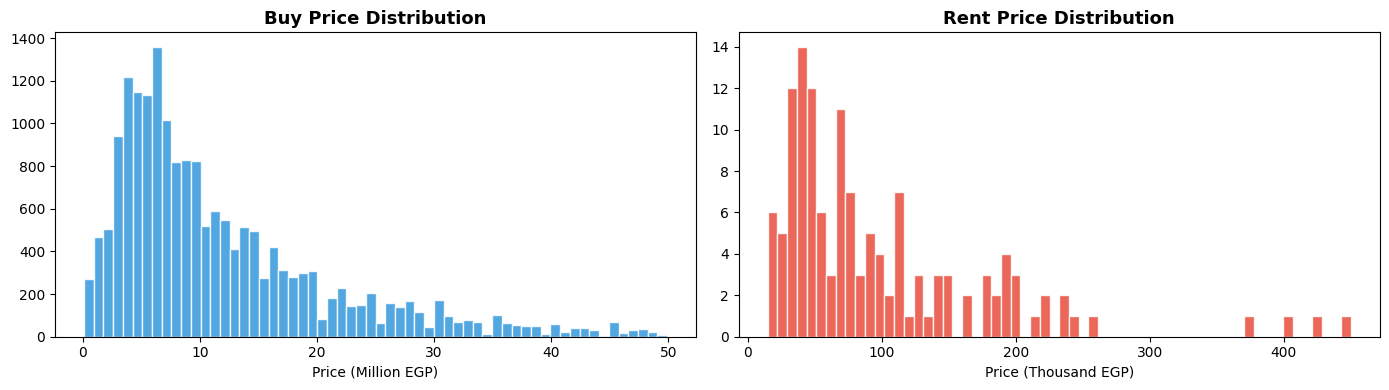

In [ ]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

# Use 'df' (the cleaned one) instead of 'df_raw'
# This avoids the casting error because price_egp is already a Double here

# 1. Prepare Buy Prices
buy_prices_pd = df.filter(
    (col("category") == "buy") & (col("price_egp") < 50_000_000)
).select(
    (col("price_egp") / 1_000_000).alias("price_m")
).toPandas()["price_m"]

# 2. Prepare Rent Prices
rent_prices_pd = df.filter(
    (col("category") == "rent") & (col("price_egp") < 500_000)
).select(
    (col("price_egp") / 1_000).alias("price_k")
).toPandas()["price_k"]

# --- PLOTTING ---
PALETTE = ["#3498db", "#e74c3c"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(buy_prices_pd, bins=60, color=PALETTE[0], edgecolor="white", alpha=0.85)
axes[0].set_title("Buy Price Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price (Million EGP)")

axes[1].hist(rent_prices_pd, bins=60, color=PALETTE[1], edgecolor="white", alpha=0.85)
axes[1].set_title("Rent Price Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Price (Thousand EGP)")

plt.tight_layout()
plt.show()

### Geographic Distribution

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Clean and Sample using Spark
map_sample_df = df_raw.dropna(subset=["lat", "lon"])

# Get the count for the sample logic
total_available = map_sample_df.count()
sample_size = min(5000, total_available)
fraction = sample_size / total_available if total_available > 0 else 0

# Convert to Pandas
sample_pd = map_sample_df.sample(withReplacement=False, fraction=fraction, seed=42).toPandas()

# --- THE FIX: Force lat/lon to be numbers ---
sample_pd["lat"] = pd.to_numeric(sample_pd["lat"], errors='coerce')
sample_pd["lon"] = pd.to_numeric(sample_pd["lon"], errors='coerce')

# Drop any rows that failed the numeric conversion
sample_pd = sample_pd.dropna(subset=["lat", "lon"])

# 2. Create the Map (Note: Plotly suggests scatter_map for newer versions, 
# but scatter_mapbox still works if you have a token or use open-street-map)
fig = px.scatter_mapbox(
    sample_pd, 
    lat="lat", 
    lon="lon",
    color="category",
    hover_data=["property_type", "city", "price_egp", "area_value"],
    color_discrete_map={"buy": "#2563EB", "rent": "#16A34A"},
    zoom=5.5, 
    height=520,
    mapbox_style="open-street-map",
    title="<b>Property Listings Map (Egypt)</b>"
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

C:\Users\mtawa\AppData\Local\Temp\ipykernel_30864\3215003854.py:24: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### Price vs Area

In [ ]:
import plotly.express as px
from pyspark.sql.functions import col, expr

# 1. Reuse our safe "try_cast" logic to get a clean base
clean_base_df = df_raw.select(
    col("category"),
    expr("try_cast(area_value as double)").alias("area_double"),
    expr("try_cast(price_egp as double)").alias("price_double")
).filter(col("area_double").isNotNull() & col("price_double").isNotNull())

# 2. Split and Sample for "Buy" (Price < 50M, Area < 1000)
buy_df = clean_base_df.filter(
    (col("category") == "buy") & 
    (col("price_double") < 50_000_000) & 
    (col("area_double") < 1000)
).sample(False, 0.2, seed=42).toPandas() # Sampling 20% for speed

# 3. Split and Sample for "Rent" (Price < 100k, Area < 500)
rent_df = clean_base_df.filter(
    (col("category") == "rent") & 
    (col("price_double") < 100_000) & 
    (col("area_double") < 500)
).sample(False, 0.5, seed=42).toPandas() # Rent is usually a smaller subset

# --- Plot 1: BUY Market ---
fig_buy = px.scatter(
    buy_df, x="area_double", y="price_double",
    trendline="ols", opacity=0.4,
    title="<b>Buy Market: Price vs Area</b>",
    labels={"area_double": "Area (sqm)", "price_double": "Price (EGP)"},
    color_discrete_sequence=["#2563EB"]
)
fig_buy.show()

# --- Plot 2: RENT Market ---
fig_rent = px.scatter(
    rent_df, x="area_double", y="price_double",
    trendline="ols", opacity=0.4,
    title="<b>Rent Market: Price vs Area</b>",
    labels={"area_double": "Area (sqm)", "price_double": "Price (EGP)"},
    color_discrete_sequence=["#16A34A"]
)
fig_rent.show()

### Correlation Heatmap

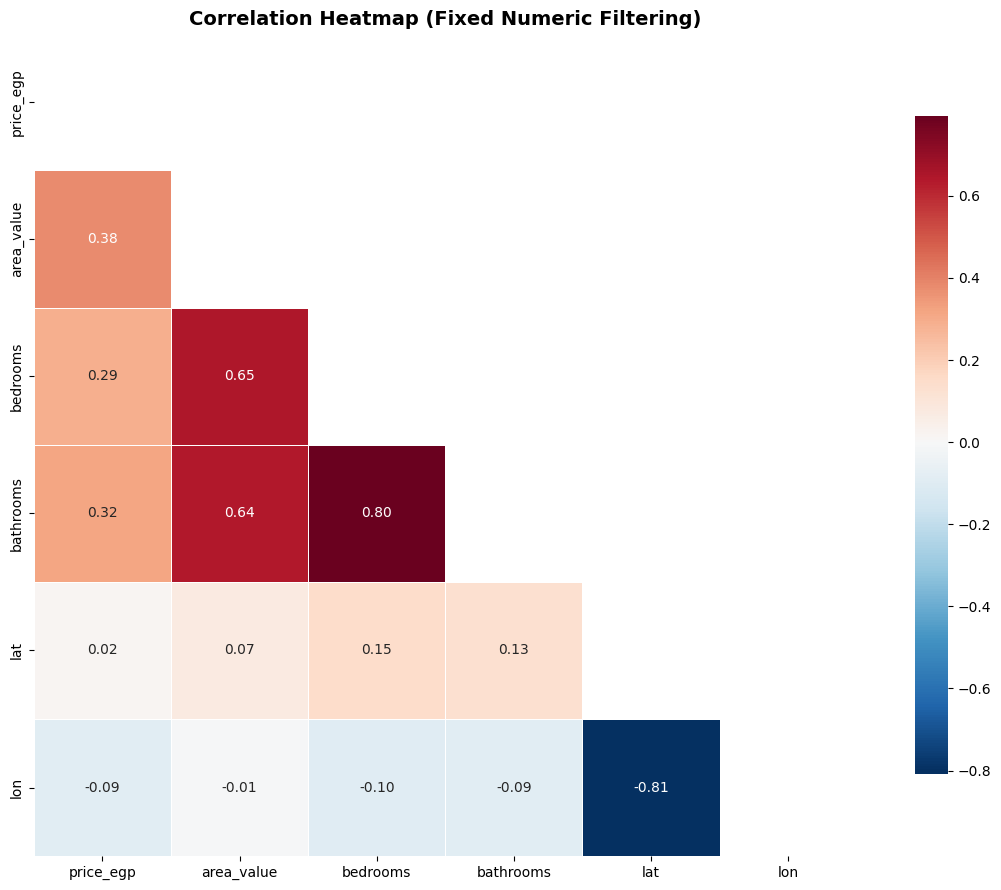

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Manually specify the columns that are DEFINITELY numeric
# This avoids the "buy" string error entirely
potential_numerics = [
    "price_egp", "area_value", "bedrooms", "bathrooms", 
    "lat", "lon", "price_per_sqm"
]

# Only use columns that actually exist in your DataFrame
corr_cols = [c for c in potential_numerics if c in df_raw.columns]

# 2. Extract and force conversion to float
# we use toPandas() on just these columns
corr_df = df_raw.select(corr_cols).toPandas()

# Convert all columns to numeric, forcing strings to NaN (which we then drop)
for col_name in corr_cols:
    corr_df[col_name] = pd.to_numeric(corr_df[col_name], errors='coerce')

# Drop any rows that turned into NaN (like the "second row from gate" text)
corr_df = corr_df.dropna()

# 3. Calculate Correlation Matrix
corr_matrix = corr_df.corr()

# 4. Plotting
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f",
    cmap="RdBu_r", 
    center=0, 
    linewidths=0.5,
    square=True, 
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap (Fixed Numeric Filtering)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Feature Engineering
This section builds the modeling features with PySpark. Raw columns are transformed into numeric representations that capture property characteristics, location quality, and listing metadata.


In [ ]:
from pyspark.sql import functions as F
from src.features.build_features import build_model_features

df = build_model_features(df, reference_date="2026-03-05", smoothing=10.0)

amenity_summary = df.agg(
    *[F.sum(c).cast("int").alias(c) for c in ["has_pool", "has_gym", "has_security", "has_parking"]]
).collect()[0].asDict()

print(f"Amenity features: {amenity_summary}")
print("Spec, temporal, and target-encoded features created with PySpark.")
print("Target encoding applied to: city, town, district, property_type")


### Feature Correlation with Target


In [ ]:
from src.features.build_features import feature_correlations
import matplotlib.pyplot as plt

feature_cols = [
    "area_value", "bedrooms", "bathrooms", "amenity_count",
    "has_pool", "has_gym", "has_security", "has_parking", "has_private_pool",
    "is_furnished", "city_enc", "district_enc", "property_type_enc",
    "days_listed", "completion_score", "log_area",
    "bed_bath_ratio", "area_per_room"
]
feature_cols = [c for c in feature_cols if c in df.columns]

corr_pd = feature_correlations(df, feature_cols, "price_per_sqm").toPandas()

PALETTE = ["#3498db", "#e74c3c", "#16a085"]
fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE[2] if v < 0 else PALETTE[0] for v in corr_pd["pearson_r"]]
ax.barh(corr_pd["feature"], corr_pd["pearson_r"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Price per sqm", fontsize=14, fontweight="bold")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.show()


### Save Feature-Engineered Data


In [ ]:
import os

output_dir = "data/processed/propertyFinder_features_csv"
os.makedirs("data/processed", exist_ok=True)

(
    df.coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(output_dir)
)

print(f"Export complete: {output_dir}")


Export Complete!


## Modeling
Fast, interpretable models are trained on buy listings, predicting log(price_per_sqm) to handle the right-skewed price distribution. All models share the same 80/20 train-test split.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor


In [ ]:
FEATURES = [
    "area_value", "log_area", "bedrooms", "bathrooms",
    "bed_bath_ratio", "total_rooms", "area_per_room", "area_x_beds",
    "lat", "lon",
    "city_enc", "town_enc", "district_enc", "property_type_enc",
    "completion_score", "is_furnished", "has_installments",
    "amenity_count", "has_pool", "has_gym", "has_security",
    "has_parking", "has_garden", "has_balcony",
    "has_private_pool", "has_spa", "has_ac",
    "days_listed",
    "is_premium", "is_verified", "is_new_construction",
    "is_direct_from_dev", "images_count",
]
TARGET = "price_per_sqm"

model_cols = FEATURES + [TARGET]
model_df = (
    df.filter(F.col("category") == "buy")
    .select(model_cols)
    .dropna()
    .toPandas()
)

for column_name in model_cols:
    model_df[column_name] = pd.to_numeric(model_df[column_name], errors="coerce")

model_df = model_df.dropna()
X = model_df[FEATURES]
y = np.log1p(model_df[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}  |  Features: {len(FEATURES)}")


In [ ]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    rmse_orig = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(preds)))
    print(f"  {name:<25s}  R2={r2:.4f}  RMSE(log)={rmse:.4f}  RMSE(EGP/sqm)={rmse_orig:,.0f}")
    return {
        "Model": name,
        "R2": r2,
        "RMSE_log": rmse,
        "MAE_log": mae,
        "RMSE_EGP": rmse_orig,
        "fitted": model,
    }


results = []
print("Training models...\n")


In [ ]:
results.append(evaluate(
    "Ridge Regression", Ridge(alpha=10),
    X_train_sc, X_test_sc, y_train, y_test
))

results.append(evaluate(
    "Lasso Regression", Lasso(alpha=0.001, max_iter=5000, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test
))

results.append(evaluate(
    "Elastic Net", ElasticNet(alpha=0.001, l1_ratio=0.3, max_iter=5000, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test
))

results.append(evaluate(
    "Shallow Decision Tree",
    DecisionTreeRegressor(max_depth=6, min_samples_leaf=50, random_state=42),
    X_train, X_test, y_train, y_test
))


### Deferred Heavy Models
Random forests, extra trees, gradient boosting, and stacking are intentionally deferred until the fast baseline pipeline and experiment reports are stable.


### Model Comparison


In [ ]:
import matplotlib.ticker as mticker

results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k != "fitted"} for r in results]
).sort_values("R2", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [PALETTE[0] if i == 0 else "#94A3B8" for i in range(len(results_df))]

axes[0].barh(results_df["Model"][::-1], results_df["R2"][::-1], color=colors[::-1])
axes[0].set_title("R2 Score (higher = better)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("R2")

axes[1].barh(results_df["Model"][::-1], results_df["RMSE_EGP"][::-1], color=colors[::-1])
axes[1].set_title("RMSE in EGP/sqm (lower = better)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("RMSE (EGP/sqm)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

results_df
